## Fase 1: Demostración del Flujo de Procesamiento (Sujeto Piloto)

Para validar nuestra metodología, ejecutaremos el flujo de trabajo paso a paso utilizando un único registro (Sujeto 1). 

### Paso 1: Selección de datos y canales de interés
Se carga el registro EEG y se aíslan exclusivamente los electrodos asociados a la corteza sensoriomotora (**C3, C4 y Cz**). A continuación, se visualiza un segmento de la señal cruda para evidenciar el nivel de ruido base antes de aplicar cualquier filtro.

Extracting EDF parameters from Sujetos/S001/S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Canales seleccionados: ['C3', 'C4', 'Cz']
Frecuencia de muestreo: 160.0 Hz
Using matplotlib as 2D backend.


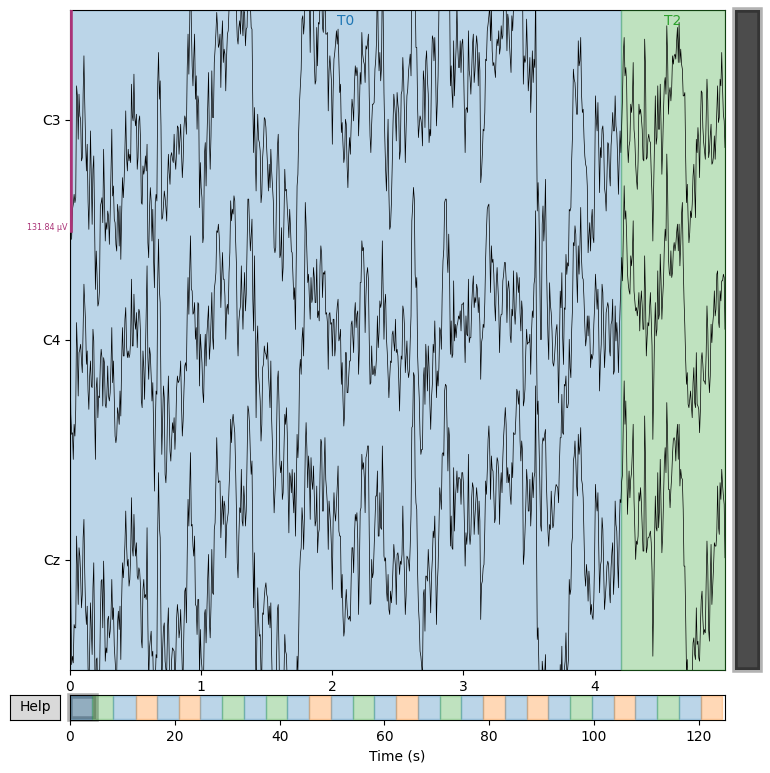

In [3]:
import mne
import matplotlib.pyplot as plt

# BLOQUE 1: CARGA DE DATOS Y VISUALIZACIÓN CRUDA


# Usamos R04 porque el README indica que ahí está la Tarea 2 (Imaginación motora de puños)
ruta_archivo = 'Sujetos/S001/S001R04.edf' 

# 2. Cargar la señal cruda
# preload=True carga la señal en memoria para poder trabajar con ella
senal_cruda = mne.io.read_raw_edf(ruta_archivo, preload=True)
mne.datasets.eegbci.standardize(senal_cruda)

# 3. Seleccionar los canales de interés
canales_motores = ['C3', 'C4', 'Cz']
senal_cruda.pick_channels(canales_motores)

# Imprimir información básica para verificar
print(f"Canales seleccionados: {senal_cruda.ch_names}")
print(f"Frecuencia de muestreo: {senal_cruda.info['sfreq']} Hz")

# 4. Visualizar 5 segundos de la señal original
# Usamos scalings='auto' para que Python ajuste el tamaño de la onda automáticamente
senal_cruda.plot(duration=5, n_channels=3, title="Bloque 1: Señal Cruda (Con Ruido)", scalings='auto')
plt.show()

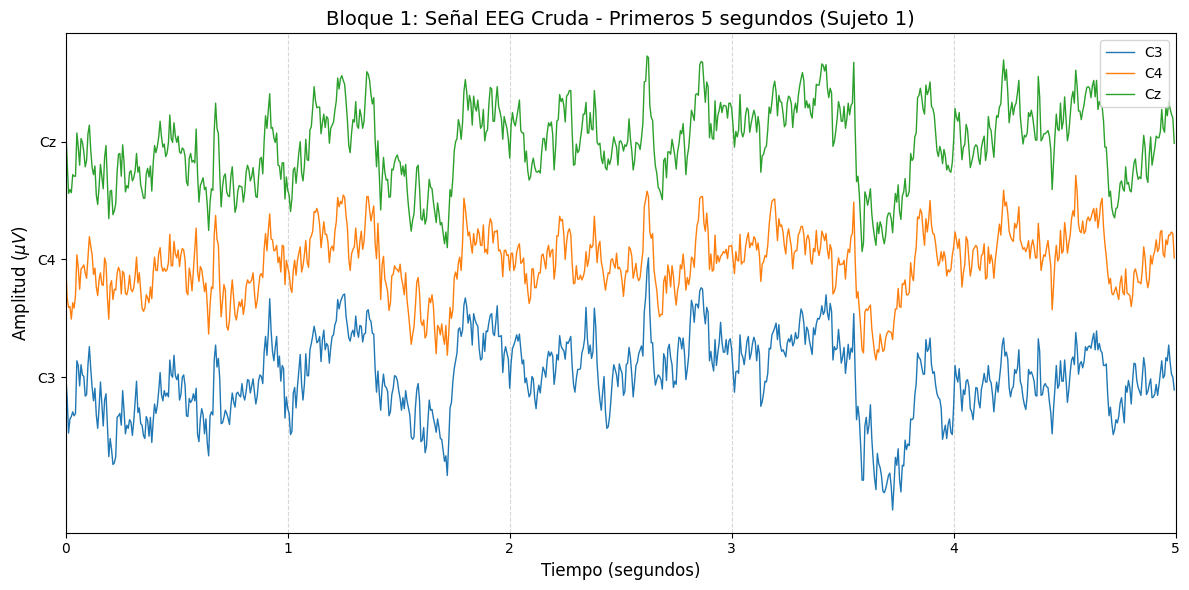

In [4]:

ruta_archivo = 'Sujetos/S001/S001R04.edf' 

# 2. Cargar la señal cruda (raw)
senal_cruda = mne.io.read_raw_edf(ruta_archivo, preload=True, verbose=False)

# Limpiar nombres de canales
mne.datasets.eegbci.standardize(senal_cruda)

# 3. Seleccionar los canales de interés 
canales_motores = ['C3', 'C4', 'Cz']
senal_cruda.pick(canales_motores)

# Obtener información necesaria para graficar
frecuencia_muestreo = senal_cruda.info['sfreq']
nombres_ch = senal_cruda.ch_names


# --------------------------4. EXTRACCIÓN DE DATOS Y GRAFICADO CON MATPLOTLIB ------------------------------------------------


# Definimos cuántos segundos queremos ver
segundos_inicio = 0
segundos_fin = 5

# Convertimos segundos a índices de la matriz de datos
inicio_idx = int(segundos_inicio * frecuencia_muestreo)
fin_idx = int(segundos_fin * frecuencia_muestreo)

# Extraemos los datos numéricos (matriz numpy) y el vector de tiempo
# get_data devuelve Voltios, los convertimos a Microvoltios (* 1e6)
datos, tiempos = senal_cruda.get_data(start=inicio_idx, stop=fin_idx, return_times=True)
datos_microvoltios = datos * 1e6

# Crear la gráfica con Matplotlib
fig, eje = plt.subplots(figsize=(12, 6))

# Graficamos cada canal con un color distinto
colores = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Azul, Naranja, Verde

for i in range(len(canales_motores)):
    # Graficamos sumando un desplazamiento (offset) para que no se superpongan
    desplazamiento = i * 150 # microvoltios
    eje.plot(tiempos, datos_microvoltios[i] + desplazamiento, 
             color=colores[i], label=canales_motores[i], lw=1)

# Configuraciones estéticas de la gráfica (Ejes en Español)
eje.set_title(f"Bloque 1: Señal EEG Cruda - Primeros {segundos_fin} segundos (Sujeto 1)", fontsize=14)
eje.set_xlabel("Tiempo (segundos)", fontsize=12)
eje.set_ylabel("Amplitud ($\mu V$)", fontsize=12)
eje.set_xlim(segundos_inicio, segundos_fin)

# Ajustar las marcas del eje Y para que muestren los nombres de los canales
eje.set_yticks([0, 150, 300])
eje.set_yticklabels(canales_motores)

eje.grid(axis='x', linestyle='--', alpha=0.5)
eje.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Bloque 2: Preprocesamiento - Filtrado Frecuencial y Comprobación (PSD)

Las señales EEG crudas presentan una baja relación señal-ruido debido a interferencias eléctricas y artefactos biológicos. Dado que los datos fueron registrados en EE. UU., se aplicará un filtro Notch a 60 Hz para eliminar el ruido de la red eléctrica. 

Posteriormente, se aplicarán dos filtros pasa-banda, el primero entre 8 Hz y 13 Hz y el segundo entre 13 y 30 Hz. Esto nos permite aislar de manera precisa los ritmos sensoriomotores $\mu$ (8-13 Hz) y $\beta$ (13-30 Hz), eliminando derivas de baja frecuencia (como parpadeos) y ruidos de alta frecuencia (como contracciones musculares). 

Para comprobar la eficacia del filtrado, se compara la Densidad Espectral de Potencia (PSD) antes y después del procesamiento.

Plotting power spectral density (dB=True).
Plotting power spectral density (dB=True).
Plotting power spectral density (dB=True).


C:\Users\MARIANA\AppData\Local\Temp\ipykernel_16468\1870076338.py:29: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd_cruda.plot(axes=ejes[0], show=False)
C:\Users\MARIANA\AppData\Local\Temp\ipykernel_16468\1870076338.py:35: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd_mu.plot(axes=ejes[1], show=False)
C:\Users\MARIANA\AppData\Local\Temp\ipykernel_16468\1870076338.py:40: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd_beta.plot(axes=ejes[2], show=False)


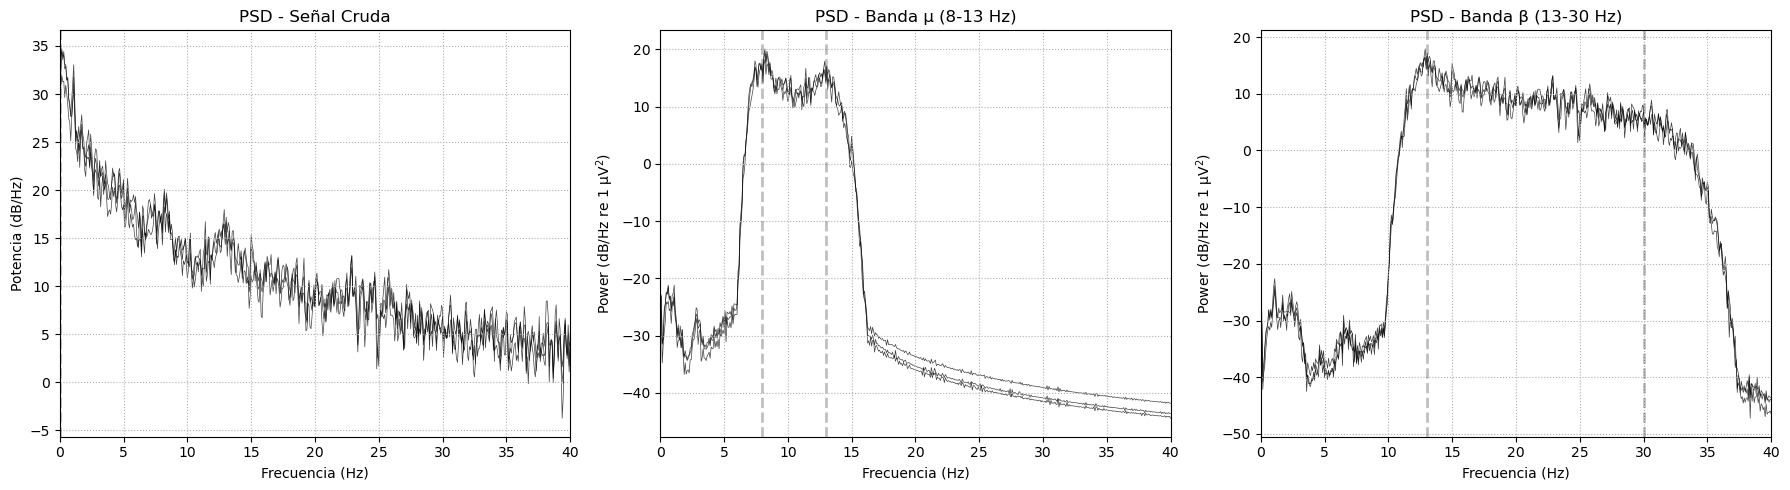

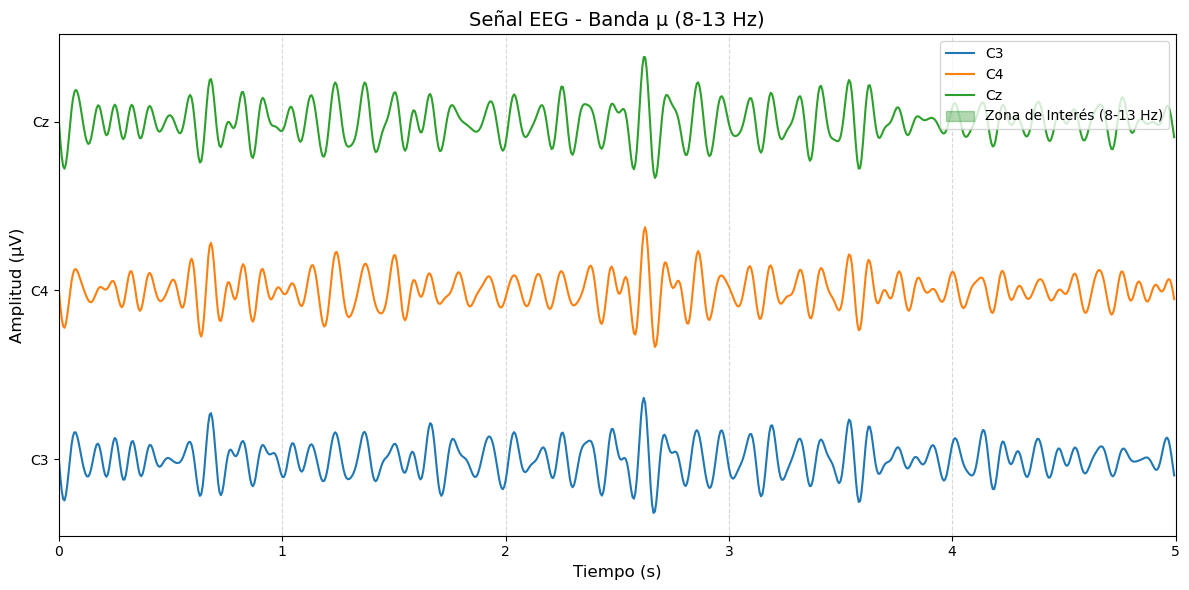

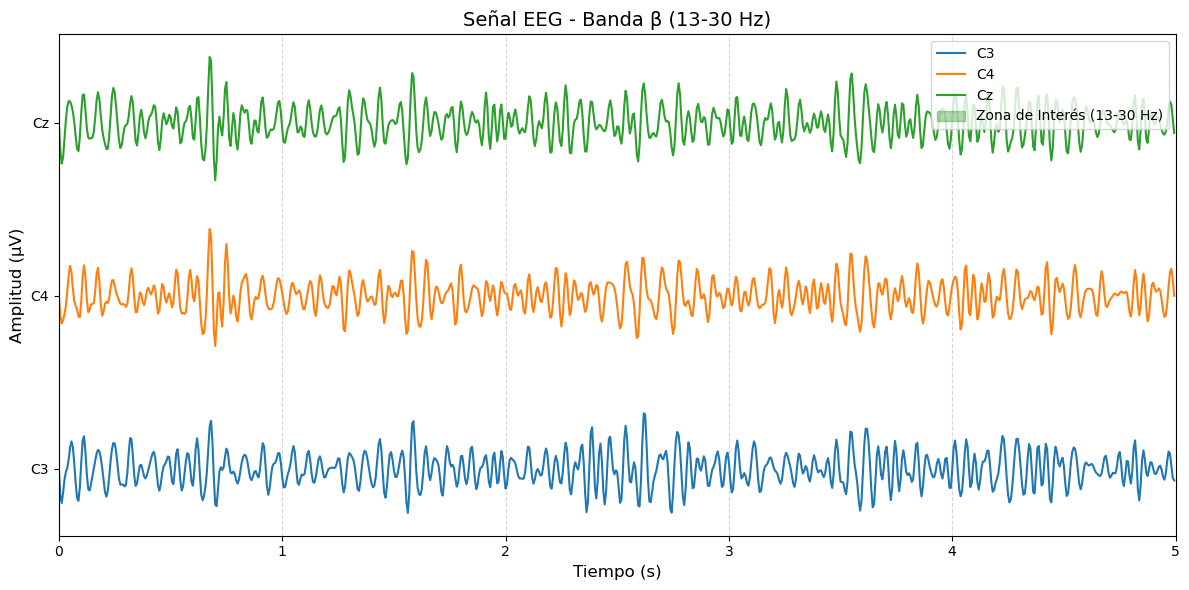

In [4]:
# --------------------------- BLOQUE 2: FILTRADO POR BANDAS μ Y β Y PSD ---------------------------

# 1. Copias de la señal cruda
senal_mu = senal_cruda.copy()
senal_beta = senal_cruda.copy()

# 2. Filtro Notch (60 Hz)
senal_mu.notch_filter(freqs=60.0, verbose=False)
senal_beta.notch_filter(freqs=60.0, verbose=False)

# 3. Filtros pasa-banda

# Banda μ (8–13 Hz)
senal_mu.filter(l_freq=8.0, h_freq=13.0, verbose=False)

# Banda β (13–30 Hz)
senal_beta.filter(l_freq=13.0, h_freq=30.0, verbose=False)

# 4. PSD (Densidad Espectral de Potencia)

psd_cruda = senal_cruda.compute_psd(fmax=40, verbose=False)
psd_mu = senal_mu.compute_psd(fmax=40, verbose=False)
psd_beta = senal_beta.compute_psd(fmax=40, verbose=False)

# 5. Comparación PSD
fig, ejes = plt.subplots(1, 3, figsize=(18, 5))

# Señal cruda
psd_cruda.plot(axes=ejes[0], show=False)
ejes[0].set_title("PSD - Señal Cruda")
ejes[0].set_xlabel("Frecuencia (Hz)")
ejes[0].set_ylabel("Potencia (dB/Hz)")

# Banda μ
psd_mu.plot(axes=ejes[1], show=False)
ejes[1].set_title("PSD - Banda μ (8-13 Hz)")
ejes[1].set_xlabel("Frecuencia (Hz)")

# Banda β
psd_beta.plot(axes=ejes[2], show=False)
ejes[2].set_title("PSD - Banda β (13-30 Hz)")
ejes[2].set_xlabel("Frecuencia (Hz)")

plt.tight_layout()
plt.show()


# --------------------------- VISUALIZACIÓN EN EL TIEMPO ---------------------------

# Obtener datos
datos_mu, tiempos = senal_mu.get_data(start=inicio_idx, stop=fin_idx, return_times=True)
datos_beta, _ = senal_beta.get_data(start=inicio_idx, stop=fin_idx, return_times=True)

# Convertir a microvoltios
datos_mu = datos_mu * 1e6
datos_beta = datos_beta * 1e6


# --------------------------- GRÁFICA BANDA μ ---------------------------
fig2, eje2 = plt.subplots(figsize=(12, 6))

for i in range(len(canales_motores)):
    desplazamiento = i * 150
    eje2.plot(tiempos, datos_mu[i] + desplazamiento,
              color=colores[i], label=canales_motores[i], lw=1.5)

eje2.set_title("Señal EEG - Banda μ (8-13 Hz)", fontsize=14)
eje2.set_xlabel("Tiempo (s)", fontsize=12)
eje2.set_ylabel("Amplitud (µV)", fontsize=12)
eje2.set_xlim(segundos_inicio, segundos_fin)
eje2.set_yticks([i * 150 for i in range(len(canales_motores))])
eje2.set_yticklabels(canales_motores)
eje2.grid(axis='x', linestyle='--', alpha=0.5)
eje2.axvspan(8, 13, color='green', alpha=0.3, label='Zona de Interés (8-13 Hz)')
eje2.legend()
eje2.legend(loc='upper right')

plt.tight_layout()
plt.show()


# --------------------------- GRÁFICA BANDA β ---------------------------
fig3, eje3 = plt.subplots(figsize=(12, 6))

for i in range(len(canales_motores)):
    desplazamiento = i * 150
    eje3.plot(tiempos, datos_beta[i] + desplazamiento,
              color=colores[i], label=canales_motores[i], lw=1.5)

eje3.set_title("Señal EEG - Banda β (13-30 Hz)", fontsize=14)
eje3.set_xlabel("Tiempo (s)", fontsize=12)
eje3.set_ylabel("Amplitud (µV)", fontsize=12)
eje3.set_xlim(segundos_inicio, segundos_fin)
eje3.set_yticks([i * 150 for i in range(len(canales_motores))])
eje3.set_yticklabels(canales_motores)
eje3.grid(axis='x', linestyle='--', alpha=0.5)
eje3.axvspan(13, 30, color='green', alpha=0.3, label='Zona de Interés (13-30 Hz)')
eje3.legend()
eje3.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Bloque 3: Segmentación de la Señal (Epoching) y Conectividad (Coherencia)

La señal continua de EEG contiene diferentes eventos correspondientes al protocolo experimental. De acuerdo con la documentación del dataset (Wadsworth Center), para la **Tarea 2** (Imaginación motora de puños), los eventos se codifican de la siguiente manera:
* **T0:** Periodo de reposo.
* **T1:** Imaginación del movimiento del puño izquierdo.
* **T2:** Imaginación del movimiento del puño derecho.

Procederemos a extraer estos marcadores y segmentar la señal continua en *epochs* (ventanas de tiempo) que inician 0.5 segundos antes del estímulo y finalizan 4 segundos después. 

Para cumplir con el requerimiento de análisis de conectividad, se calculará la **Coherencia de magnitud al cuadrado** entre los electrodos interhemisféricos (C3 y C4) para un *epoch* específico de imaginación motora, permitiendo observar la sincronización de las áreas motoras izquierda y derecha en el dominio de la frecuencia.

In [5]:
import numpy as np

# Eventos
eventos, eventos_dict = mne.events_from_annotations(senal_mu, verbose=False)

mapeo_eventos = {}

for clave, valor in eventos_dict.items():
        if clave == 'T0': mapeo_eventos['Reposo'] = valor
        elif clave == 'T1': mapeo_eventos['Imag_Izquierda'] = valor
        elif clave == 'T2': mapeo_eventos['Imag_Derecha'] = valor

# Epochs mu
epochs_mu = mne.Epochs(
   senal_mu, eventos, event_id=mapeo_eventos,
    tmin=-0.5, tmax=4.0,
    baseline=(-0.5, 0),
    preload=True, verbose=False
    )

# Tomar un epoch de ejemplo
epoch = epochs_mu['Imag_Derecha'].get_data(copy=True)[0]

# Índices C3 y C4
idx_c3 = epochs_mu.ch_names.index('C3')
idx_c4 = epochs_mu.ch_names.index('C4')

# Coherencia
from scipy.signal import coherence
data_mu = epochs_mu['Imag_Derecha'].get_data()

coherencias_mu = []

for epoch in data_mu:
    c3 = epoch[idx_c3]
    c4 = epoch[idx_c4]

    f_mu, coh = coherence(c3, c4, fs=frecuencia_muestreo, nperseg=256)
    coherencias_mu.append(coh)

coh_mu = np.mean(coherencias_mu, axis=0)

# Epochs beta
epochs_beta = mne.Epochs(
   senal_beta, eventos, event_id=mapeo_eventos,
    tmin=-0.5, tmax=4.0,
    baseline=(-0.5, 0),
    preload=True, verbose=False
    )

# Tomar un epoch de ejemplo
epoch = epochs_beta['Imag_Derecha'].get_data(copy=True)[0]

# Índices C3 y C4
idx_c3 = epochs_beta.ch_names.index('C3')
idx_c4 = epochs_beta.ch_names.index('C4')

# Coherencia
from scipy.signal import coherence
data_beta = epochs_beta['Imag_Derecha'].get_data()

coherencias_beta = []

for epoch in data_beta:
    c3 = epoch[idx_c3]
    c4 = epoch[idx_c4]

    f_beta, coh = coherence(c3, c4, fs=frecuencia_muestreo, nperseg=256)
    coherencias_beta.append(coh)

coh_beta = np.mean(coherencias_beta, axis=0)


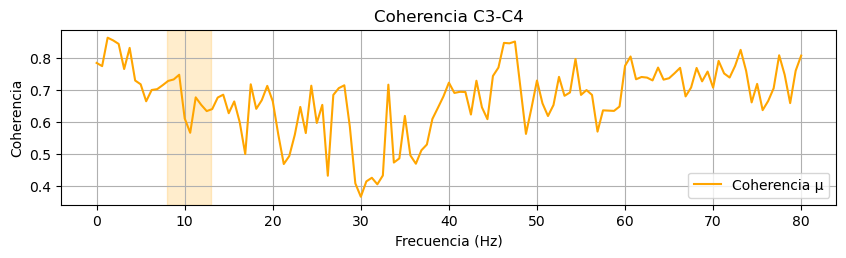

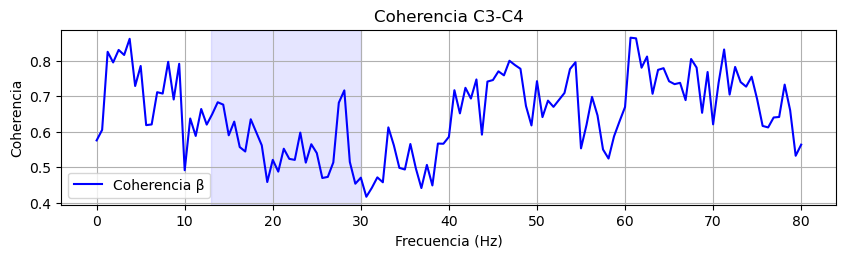

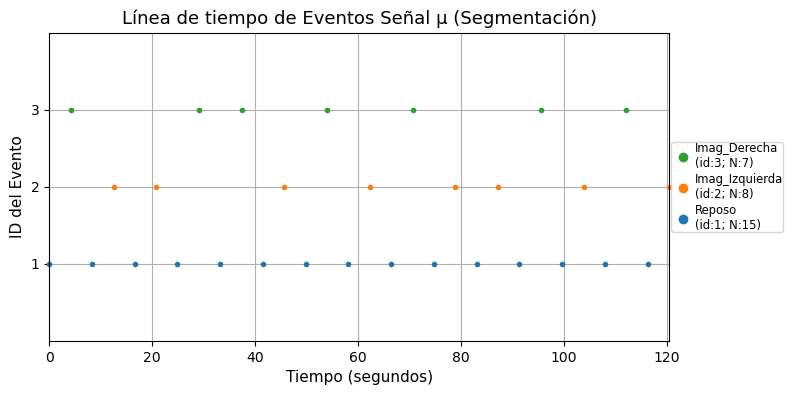

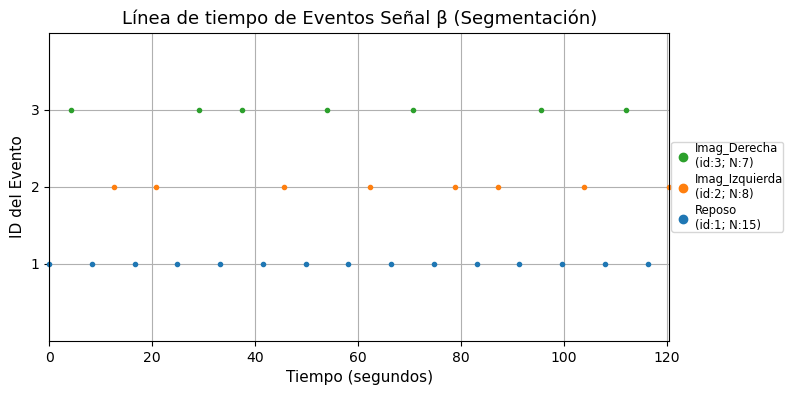

In [6]:
plt.figure(figsize=(10,5))

plt.subplot(2, 1, 1)
plt.title("Coherencia C3-C4")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Coherencia")
plt.plot(f_mu, coh_mu, label='Coherencia μ', color='orange')
plt.axvspan(8, 13, color='orange', alpha=0.2)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.subplot(2, 1, 2)
plt.plot(f_beta, coh_beta, label='Coherencia β', color='blue')
plt.title("Coherencia C3-C4")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Coherencia")
plt.axvspan(13, 30, color='blue', alpha=0.1)
plt.legend()
plt.grid(True)
plt.show()

# Línea de tiempo de eventos 
# Señal mu
fig1, ax1 = plt.subplots(figsize=(10, 4))
mne.viz.plot_events(eventos, sfreq=frecuencia_muestreo, first_samp=senal_mu.first_samp,
                    event_id=mapeo_eventos, axes=ax1, show=False)

ax1.set_title("Línea de tiempo de Eventos Señal μ (Segmentación)", fontsize=13)
ax1.set_xlabel("Tiempo (segundos)", fontsize=11)
ax1.set_ylabel("ID del Evento", fontsize=11)

plt.show()

#Señal beta
fig2, ax2 = plt.subplots(figsize=(10, 4))
mne.viz.plot_events(eventos, sfreq=frecuencia_muestreo, first_samp=senal_beta.first_samp,
                    event_id=mapeo_eventos, axes=ax2, show=False)

ax2.set_title("Línea de tiempo de Eventos Señal β (Segmentación)", fontsize=13)
ax2.set_xlabel("Tiempo (segundos)", fontsize=11)
ax2.set_ylabel("ID del Evento", fontsize=11)

plt.show()


La coherencia interhemisférica se calculó de forma independiente para las bandas μ y β, utilizando señales previamente filtradas en cada rango. Esto permitió evaluar la sincronización funcional específica de cada banda durante la imaginación motora.

### Bloque 4: Extracción de Características, ERD/ERS y Coherencia

En esta fase, transformamos la señal temporal en características en el dominio de la frecuencia. Este proceso se divide en tres partes fundamentales:

1. **Identificación de ERD/ERS (Análisis Tiempo-Frecuencia):** Utilizamos la transformada Wavelet de Morlet para visualizar cómo cambia la potencia espectral a lo largo del tiempo en comparación con el periodo de reposo (*baseline* de -0.5 a 0 s). Una caída en la potencia se conoce como ERD (asociada a la activación motora), y un aumento como ERS.
2. **Densidad Espectral de Potencia (PSD):** Se calcula la potencia absoluta en las bandas de interés ($\mu$: 8-13 Hz y $\beta$: 14-30 Hz) exclusivamente durante la ventana de imaginación motora (0 a 4 segundos).
3. **Características de Coherencia:** Cuantificamos el nivel de sincronización interhemisférica (C3-C4) promedio para cada época en ambas bandas, consolidando el biomarcador de conectividad.

In [7]:
# --------------------------- BLOQUE 4: EXTRACCIÓN DE CARACTERÍSTICAS ---------------------------

import numpy as np
from scipy.signal import welch

# Definir bandas
bandas = {
    'mu': (8, 13),
    'beta': (13, 30)
}

# Frecuencia de muestreo
fs = frecuencia_muestreo

# Lista donde guardaremos resultados
resultados = []

# Función para calcular potencia en banda
def calcular_potencia_banda(signal, fs, banda):
    f, psd = welch(signal, fs=fs, nperseg=256)
    idx = np.logical_and(f >= banda[0], f <= banda[1])
    return np.mean(psd[idx])

# --------------------------- RECORRER EPOCHS μ ---------------------------

epochs_data_mu = epochs_mu.get_data()
labels = epochs_mu.events[:, -1]

for i, epoch in enumerate(epochs_data_mu):

    # Canales
    c3 = epoch[epochs_mu.ch_names.index('C3')]
    c4 = epoch[epochs_mu.ch_names.index('C4')]
    cz = epoch[epochs_mu.ch_names.index('Cz')]

    # Potencia μ
    pot_mu_c3 = calcular_potencia_banda(c3, fs, bandas['mu'])
    pot_mu_c4 = calcular_potencia_banda(c4, fs, bandas['mu'])
    pot_mu_cz = calcular_potencia_banda(cz, fs, bandas['mu'])

    resultados.append({
        'Sujeto': 'S001',
        'Condicion': labels[i],
        'Pot_Mu_C3': pot_mu_c3,
        'Pot_Mu_C4': pot_mu_c4,
        'Pot_Mu_Cz': pot_mu_cz
    })

# --------------------------- RECORRER EPOCHS β ---------------------------

epochs_data_beta = epochs_beta.get_data()

for i, epoch in enumerate(epochs_data_beta):

    c3 = epoch[epochs_beta.ch_names.index('C3')]
    c4 = epoch[epochs_beta.ch_names.index('C4')]
    cz = epoch[epochs_beta.ch_names.index('Cz')]

    # Potencia β
    pot_beta_c3 = calcular_potencia_banda(c3, fs, bandas['beta'])
    pot_beta_c4 = calcular_potencia_banda(c4, fs, bandas['beta'])
    pot_beta_cz = calcular_potencia_banda(cz, fs, bandas['beta'])

    # Agregar al mismo registro (mismo índice)
    resultados[i]['Pot_Beta_C3'] = pot_beta_c3
    resultados[i]['Pot_Beta_C4'] = pot_beta_c4
    resultados[i]['Pot_Beta_Cz'] = pot_beta_cz

# --------------------------- COHERENCIA PROMEDIO ---------------------------

from scipy.signal import coherence

for i, epoch in enumerate(epochs_data_mu):

    c3 = epoch[epochs_mu.ch_names.index('C3')]
    c4 = epoch[epochs_mu.ch_names.index('C4')]

    f, coh = coherence(c3, c4, fs=fs, nperseg=256)

    # Banda μ
    idx_mu = np.logical_and(f >= 8, f <= 13)
    coh_mu = np.mean(coh[idx_mu])

    # Banda β
    idx_beta = np.logical_and(f >= 13, f <= 30)
    coh_beta = np.mean(coh[idx_beta])

    resultados[i]['Coh_Mu_C3_C4'] = coh_mu
    resultados[i]['Coh_Beta_C3_C4'] = coh_beta

# --------------------------- CONVERTIR A DATAFRAME ---------------------------

import pandas as pd

df_final = pd.DataFrame(resultados)

# --------------------------- MAPEAR ETIQUETAS ---------------------------

mapa_labels = {
    1: 'Reposo',
    2: 'Izquierda',
    3: 'Derecha'
}

df_final['Condicion'] = df_final['Condicion'].map(mapa_labels)

print(df_final.head())

  Sujeto  Condicion     Pot_Mu_C3     Pot_Mu_C4     Pot_Mu_Cz   Pot_Beta_C3  \
0   S001    Derecha  3.307388e-11  2.854099e-11  3.415663e-11  8.827647e-12   
1   S001     Reposo  3.106517e-11  2.168657e-11  3.054003e-11  1.279652e-11   
2   S001  Izquierda  3.244881e-11  2.712172e-11  3.484462e-11  8.443393e-12   
3   S001     Reposo  3.013282e-11  2.871886e-11  3.223718e-11  8.386744e-12   
4   S001  Izquierda  3.226287e-11  1.758818e-11  2.746994e-11  9.117284e-12   

    Pot_Beta_C4   Pot_Beta_Cz  Coh_Mu_C3_C4  Coh_Beta_C3_C4  
0  8.400517e-12  9.570869e-12      0.607778        0.705747  
1  7.971162e-12  1.130720e-11      0.702695        0.605021  
2  6.593016e-12  7.899265e-12      0.736103        0.511500  
3  7.614430e-12  8.641703e-12      0.524523        0.530400  
4  7.482929e-12  9.096404e-12      0.760360        0.709492  


Se calcularon características espectrales a partir de cada epoch utilizando el método de Welch para estimar la densidad espectral de potencia.

Se extrajo la potencia promedio en las bandas μ (8–13 Hz) y β (13–30 Hz) para los canales C3, C4 y Cz, debido a su relevancia en tareas de imaginación motora.

Adicionalmente, se calculó la coherencia interhemisférica (C3–C4) en ambas bandas, permitiendo evaluar la conectividad funcional.

Los cambios en la potencia permitieron identificar fenómenos de ERD (disminución de potencia) y ERS (incremento), asociados a la activación cortical durante la tarea.

NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: percent)
No baseline correction applied


<Figure size 800x600 with 0 Axes>

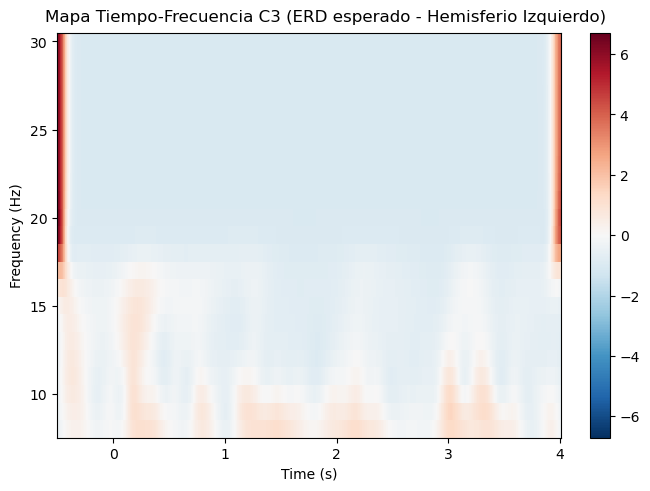

No baseline correction applied


<Figure size 800x600 with 0 Axes>

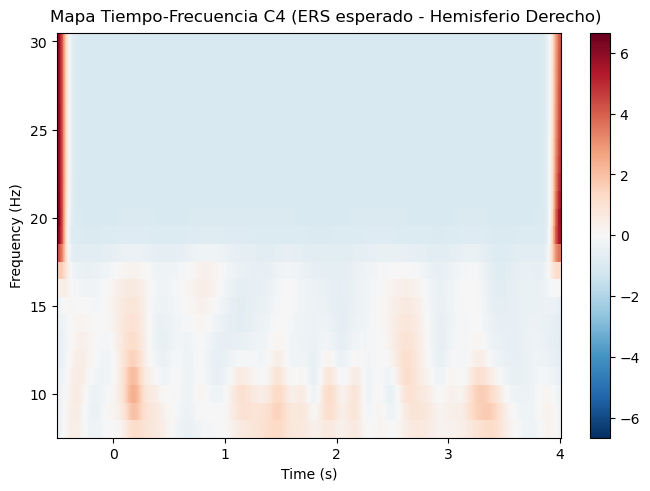

[<Figure size 640x480 with 2 Axes>]

In [8]:
# Fecuencias de interes 
frecuencias = np.arange(8, 31, 1)  # 8 a 30 Hz
n_ciclos = frecuencias / 2         # recomendado

# Sekeccionar epochs imaginacion derecha 
epochs_derecha = epochs_mu['Imag_Derecha']

# Transformada tiempo-frecuencia
from mne.time_frequency import tfr_morlet

tfr = tfr_morlet(
    epochs_derecha,
    freqs=frecuencias,
    n_cycles=n_ciclos,
    return_itc=False,
    average=True
)

# Baseline
# Esto convierte a % de cambio vs reposo
tfr.apply_baseline(baseline=(-0.5, 0), mode='percent')

# Grafica C3 (ERD esperado)
plt.figure(figsize=(8,6))

tfr.plot(
    picks=['C3'],
    title="Mapa Tiempo-Frecuencia C3 (ERD esperado - Hemisferio Izquierdo)",
    cmap='RdBu_r',      # azul = ERD, rojo = ERS
    show=True
)

# Grafica C4 (ERS o menor ERD)
plt.figure(figsize=(8,6))

tfr.plot(
    picks=['C4'],
    title="Mapa Tiempo-Frecuencia C4 (ERS esperado - Hemisferio Derecho)",
    cmap='RdBu_r',      # azul = ERD, rojo = ERS
    show=True
)


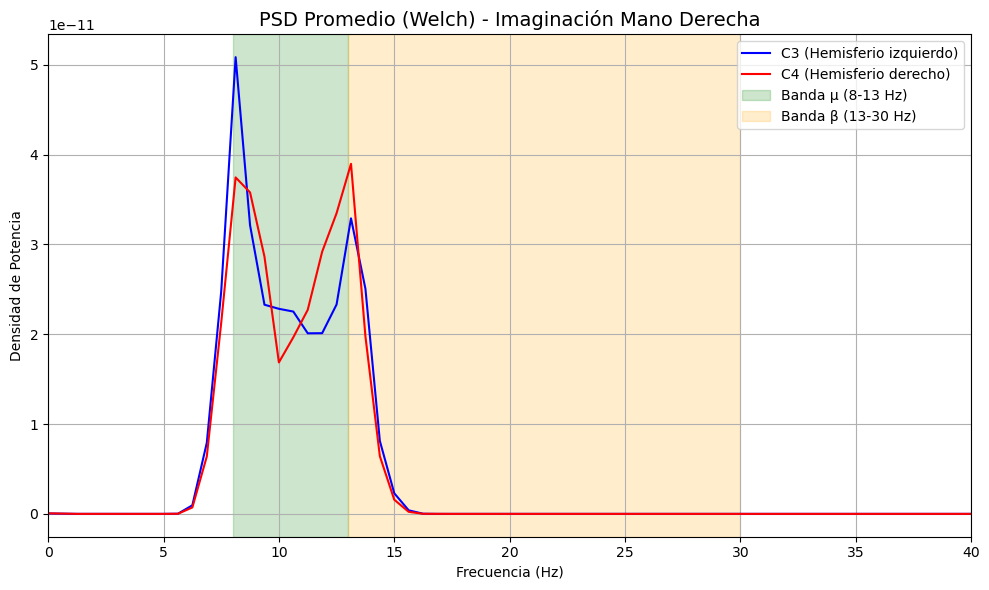

In [9]:
# --------------------------- PSD POR WELCH (PROMEDIO POR CONDICIÓN) ---------------------------

from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt

# Seleccionar epochs de imaginación derecha
epochs_der_mu = epochs_mu['Imag_Derecha']
epochs_der_beta = epochs_beta['Imag_Derecha']

# Obtener datos
data_mu = epochs_der_mu.get_data()   # shape: (n_epochs, n_canales, n_times)
data_beta = epochs_der_beta.get_data()

# Índices de canales
idx_c3 = epochs_mu.ch_names.index('C3')
idx_c4 = epochs_mu.ch_names.index('C4')

# Inicializar listas
psd_c3_total = []
psd_c4_total = []

# ------------------- CALCULAR PSD PARA CADA EPOCH -------------------

for epoch in data_mu:

    c3 = epoch[idx_c3]
    c4 = epoch[idx_c4]

    f, psd_c3 = welch(c3, fs=frecuencia_muestreo, nperseg=256)
    _, psd_c4 = welch(c4, fs=frecuencia_muestreo, nperseg=256)

    psd_c3_total.append(psd_c3)
    psd_c4_total.append(psd_c4)

# ------------------- PROMEDIO -------------------

psd_c3_mean = np.mean(psd_c3_total, axis=0)
psd_c4_mean = np.mean(psd_c4_total, axis=0)

# ------------------- GRÁFICA -------------------

plt.figure(figsize=(10,6))

plt.plot(f, psd_c3_mean, label='C3 (Hemisferio izquierdo)', color='blue')
plt.plot(f, psd_c4_mean, label='C4 (Hemisferio derecho)', color='red')

# Bandas de interés
plt.axvspan(8, 13, color='green', alpha=0.2, label='Banda μ (8-13 Hz)')
plt.axvspan(13, 30, color='orange', alpha=0.2, label='Banda β (13-30 Hz)')

plt.title("PSD Promedio (Welch) - Imaginación Mano Derecha", fontsize=14)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Densidad de Potencia")
plt.xlim(0, 40)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Bloque 5: Organización de Datos y Estructuración Final

Para concluir el flujo de procesamiento del sujeto piloto, consolidamos todas las características extraídas en un **DataFrame maestro estructurado**. Esta tabla representa el insumo final para cualquier análisis estadístico posterior o para el entrenamiento de modelos de clasificación (Machine Learning).

Cada fila de este dataset corresponde a un **epoch** (un intento de imaginación o reposo) y contiene:
* **Metadatos:** Identificación del sujeto y la tarea realizada.
* **Potencia Espectral (PSD):** Energía en las bandas $\mu$ y $\beta$ para los canales clave (C3, C4, Cz).
* **Conectividad Funcional (Coherencia):** Nivel de sincronización interhemisférica (C3-C4) y con el vértex (C3-Cz, C4-Cz).

In [10]:
# --------------------------- BLOQUE 5: ORGANIZACIÓN DE DATOS ---------------------------

import pandas as pd
import numpy as np
from scipy.signal import welch, coherence

# Frecuencia de muestreo
fs = frecuencia_muestreo

# Definir bandas
bandas = {
    'mu': (8, 13),
    'beta': (13, 30)
}

# Función potencia
def potencia_banda(signal, fs, banda):
    f, psd = welch(signal, fs=fs, nperseg=256)
    idx = np.logical_and(f >= banda[0], f <= banda[1])
    return np.mean(psd[idx])

# Lista final
filas = []

# --------------------------- RECORRER EPOCHS ---------------------------

epochs_data = epochs_mu.get_data()  # usamos mismos epochs
labels = epochs_mu.events[:, -1]

# Índices canales
idx_c3 = epochs_mu.ch_names.index('C3')
idx_c4 = epochs_mu.ch_names.index('C4')
idx_cz = epochs_mu.ch_names.index('Cz')

for i, epoch in enumerate(epochs_data):

    c3 = epoch[idx_c3]
    c4 = epoch[idx_c4]
    cz = epoch[idx_cz]

    # ---------------- POTENCIA ----------------
    pot_mu_c3 = potencia_banda(c3, fs, bandas['mu'])
    pot_mu_c4 = potencia_banda(c4, fs, bandas['mu'])
    pot_mu_cz = potencia_banda(cz, fs, bandas['mu'])

    pot_beta_c3 = potencia_banda(c3, fs, bandas['beta'])
    pot_beta_c4 = potencia_banda(c4, fs, bandas['beta'])
    pot_beta_cz = potencia_banda(cz, fs, bandas['beta'])

    # ---------------- COHERENCIA ----------------
    f, coh_c3c4 = coherence(c3, c4, fs=fs, nperseg=256)
    _, coh_c3cz = coherence(c3, cz, fs=fs, nperseg=256)
    _, coh_c4cz = coherence(c4, cz, fs=fs, nperseg=256)

    coh_mu = np.mean(coh_c3c4[(f >= 8) & (f <= 13)])
    coh_beta = np.mean(coh_c3c4[(f >= 13) & (f <= 30)])

    coh_mu_c3cz = np.mean(coh_c3cz[(f >= 8) & (f <= 13)])
    coh_mu_c4cz = np.mean(coh_c4cz[(f >= 8) & (f <= 13)])

    coh_beta_c3cz = np.mean(coh_c3cz[(f >= 13) & (f <= 30)])
    coh_beta_c4cz = np.mean(coh_c4cz[(f >= 13) & (f <= 30)])

    # ---------------- GUARDAR FILA ----------------
    filas.append({
        'Sujeto': 'S001',
        'Condicion': labels[i],

        'Pot_Mu_C3': pot_mu_c3,
        'Pot_Mu_C4': pot_mu_c4,
        'Pot_Mu_Cz': pot_mu_cz,

        'Pot_Beta_C3': pot_beta_c3,
        'Pot_Beta_C4': pot_beta_c4,
        'Pot_Beta_Cz': pot_beta_cz,

        'Coh_Mu_C3_C4': coh_mu,
        'Coh_Mu_C3_Cz': coh_mu_c3cz,
        'Coh_Mu_C4_Cz': coh_mu_c4cz,

        'Coh_Beta_C3_C4': coh_beta,
        'Coh_Beta_C3_Cz': coh_beta_c3cz,
        'Coh_Beta_C4_Cz': coh_beta_c4cz
    })

# --------------------------- DATAFRAME FINAL ---------------------------

df_final = pd.DataFrame(filas)

# Mapear etiquetas
mapa = {
    1: 'Reposo',
    2: 'Izquierda',
    3: 'Derecha'
}

df_final['Condicion'] = df_final['Condicion'].map(mapa)

print(df_final.head())

  Sujeto  Condicion     Pot_Mu_C3     Pot_Mu_C4     Pot_Mu_Cz   Pot_Beta_C3  \
0   S001    Derecha  3.307388e-11  2.854099e-11  3.415663e-11  1.353459e-12   
1   S001     Reposo  3.106517e-11  2.168657e-11  3.054003e-11  1.682364e-12   
2   S001  Izquierda  3.244881e-11  2.712172e-11  3.484462e-11  7.153926e-13   
3   S001     Reposo  3.013282e-11  2.871886e-11  3.223718e-11  2.342098e-12   
4   S001  Izquierda  3.226287e-11  1.758818e-11  2.746994e-11  1.982377e-12   

    Pot_Beta_C4   Pot_Beta_Cz  Coh_Mu_C3_C4  Coh_Mu_C3_Cz  Coh_Mu_C4_Cz  \
0  1.114329e-12  1.603993e-12      0.607778      0.842584      0.820075   
1  5.281846e-13  1.217911e-12      0.702695      0.817308      0.850854   
2  9.356426e-13  8.343969e-13      0.736103      0.829735      0.922996   
3  2.027516e-12  2.344318e-12      0.524523      0.806219      0.752062   
4  1.479754e-12  1.811421e-12      0.760360      0.895360      0.838314   

   Coh_Beta_C3_C4  Coh_Beta_C3_Cz  Coh_Beta_C4_Cz  
0        0.705747     

In [11]:
# --------------------- BLOQUE 6: PROCESAMIENTO RUN 3 Y RESUMEN ESTADÍSTICO----------------------------------------

# 1. Cargar y preparar el archivo Run 3
ruta_run3 = 'Sujetos/S001R03.edf' 
raw_real = mne.io.read_raw_edf(ruta_run3, preload=True, verbose=False)
mne.datasets.eegbci.standardize(raw_real)
raw_real.set_montage('standard_1020', match_case=False)

# 2. Filtrado
raw_real.notch_filter(60.0, verbose=False)
raw_real.filter(8.0, 30.0, verbose=False)

# 3. Epoching
eventos_real, eventos_dict_real = mne.events_from_annotations(raw_real, verbose=False)

mapeo_eventos_real = {}
for clave, valor in eventos_dict_real.items():
    if clave == 'T0': mapeo_eventos_real['Reposo'] = valor
    elif clave == 'T1': mapeo_eventos_real['Izquierda'] = valor
    elif clave == 'T2': mapeo_eventos_real['Derecha'] = valor

epochs_real = mne.Epochs(raw_real, eventos_real, event_id=mapeo_eventos_real, 
                         tmin=-0.5, tmax=4.0, baseline=(-0.5, 0), preload=True, verbose=False)

# 4. Extracción de Potencia (Welch) para Run 3
psd_real = epochs_real.compute_psd(method='welch', fmin=8, fmax=30, tmin=0, tmax=4.0, verbose=False)
datos_psd_real = psd_real.get_data() * 1e12 # Escala a microVoltios
freqs_real = psd_real.freqs

pot_mu_real = np.mean(datos_psd_real[:, :, (freqs_real >= 8) & (freqs_real <= 13)], axis=2)

# 5. Extracción de Coherencia para Run 3
datos_tiempo_real = epochs_real.copy().crop(tmin=0, tmax=4.0).get_data(copy=True)
coh_mu_C3C4_real = np.zeros(len(epochs_real))

for i in range(len(epochs_real)):
    f, c = coherence(datos_tiempo_real[i, idx_c3, :], datos_tiempo_real[i, idx_c4, :], fs=frecuencia_muestreo, nperseg=256)
    coh_mu_C3C4_real[i] = np.mean(c[(f >= 8) & (f <= 13)])

# 6. Armar DataFrame Run 3
df_real = pd.DataFrame({
    'Sujeto': 'S001',
    'Condicion': epochs_real.events[:, -1],
    'Tipo': 'Movimiento Real',
    'Pot_Mu_C3': pot_mu_real[:, idx_c3],
    'Pot_Mu_C4': pot_mu_real[:, idx_c4],
    'Coh_Mu_C3_C4': coh_mu_C3C4_real
})

mapa_inverso_real = {v: k for k, v in mapeo_eventos_real.items()}
df_real['Condicion'] = df_real['Condicion'].map(mapa_inverso_real)

# 7. Unir Run 3 y Run 4 en un solo DataFrame
df_final_mod = df_final.copy()
df_final_mod['Condicion'] = df_final_mod['Condicion'].str.replace('Imag_', '') 
df_final_mod['Tipo'] = 'Imaginación Motora'

df_combinado = pd.concat([df_real, df_final_mod[['Sujeto', 'Condicion', 'Tipo', 'Pot_Mu_C3', 'Pot_Mu_C4', 'Coh_Mu_C3_C4']]], ignore_index=True)

# 8. ANÁLISIS ESTADÍSTICO NUMÉRICO

# Agrupamos por el Tipo de tarea (Real vs Imaginada) y la Condición (Reposo, Izquierda, Derecha)
# Calculamos el promedio de la potencia y la coherencia
tabla_resumen = df_combinado.groupby(['Tipo', 'Condicion'])[['Pot_Mu_C3', 'Pot_Mu_C4', 'Coh_Mu_C3_C4']].mean()

# Formateamos para que se vea ordenado a 4 decimales
tabla_resumen = tabla_resumen.round(4)

print("\n--- RESUMEN ESTADÍSTICO DE LATERALIDAD Y CONECTIVIDAD (Promedios) ---")
display(tabla_resumen)


--- RESUMEN ESTADÍSTICO DE LATERALIDAD Y CONECTIVIDAD (Promedios) ---


Pot_Mu_C3  Pot_Mu_C4  Coh_Mu_C3_C4
Tipo               Condicion                                    
Imaginación Motora Derecha       0.0000     0.0000        0.6693
                   Izquierda     0.0000     0.0000        0.7133
                   Reposo        0.0000     0.0000        0.6221
Movimiento Real    Derecha      29.3299    31.4437        0.9341
                   Izquierda    33.1117    35.9584        0.9267
                   Reposo       35.0275    40.2455        0.9336

In [12]:
print(df_final_mod.columns)
print(df_final_mod.head())

Index(['Sujeto', 'Condicion', 'Pot_Mu_C3', 'Pot_Mu_C4', 'Pot_Mu_Cz',
       'Pot_Beta_C3', 'Pot_Beta_C4', 'Pot_Beta_Cz', 'Coh_Mu_C3_C4',
       'Coh_Mu_C3_Cz', 'Coh_Mu_C4_Cz', 'Coh_Beta_C3_C4', 'Coh_Beta_C3_Cz',
       'Coh_Beta_C4_Cz', 'Tipo'],
      dtype='object')
  Sujeto  Condicion     Pot_Mu_C3     Pot_Mu_C4     Pot_Mu_Cz   Pot_Beta_C3  \
0   S001    Derecha  3.307388e-11  2.854099e-11  3.415663e-11  1.353459e-12   
1   S001     Reposo  3.106517e-11  2.168657e-11  3.054003e-11  1.682364e-12   
2   S001  Izquierda  3.244881e-11  2.712172e-11  3.484462e-11  7.153926e-13   
3   S001     Reposo  3.013282e-11  2.871886e-11  3.223718e-11  2.342098e-12   
4   S001  Izquierda  3.226287e-11  1.758818e-11  2.746994e-11  1.982377e-12   

    Pot_Beta_C4   Pot_Beta_Cz  Coh_Mu_C3_C4  Coh_Mu_C3_Cz  Coh_Mu_C4_Cz  \
0  1.114329e-12  1.603993e-12      0.607778      0.842584      0.820075   
1  5.281846e-13  1.217911e-12      0.702695      0.817308      0.850854   
2  9.356426e-13  8.343969e-13   

### Bloque 6: ANALISIS DE DATOS

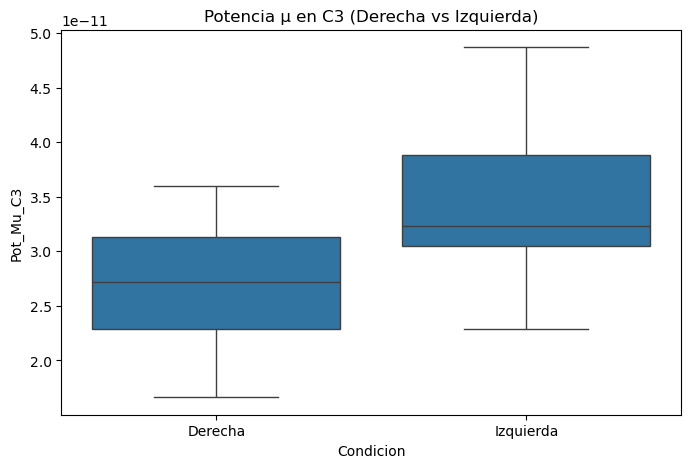

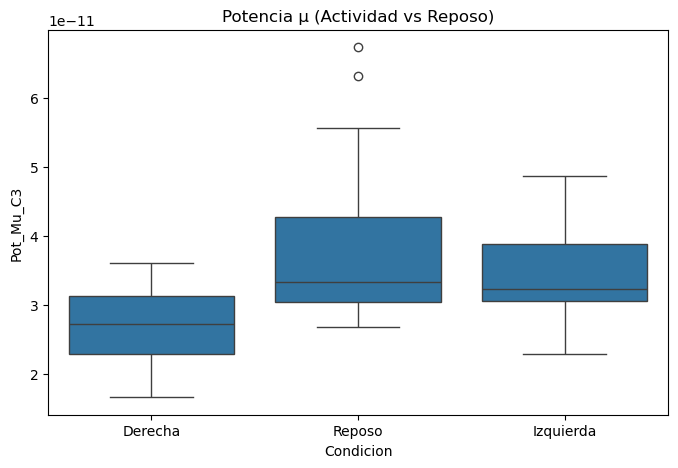

C:\Users\MARIANA\AppData\Local\Temp\ipykernel_16468\2654532230.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['C3', 'C4'])


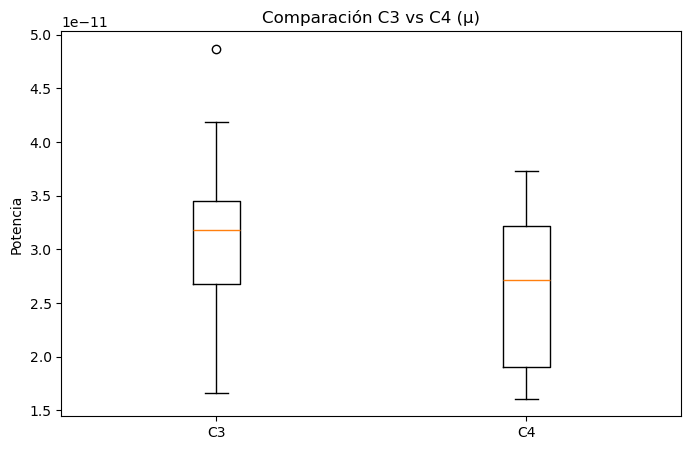

C:\Users\MARIANA\AppData\Local\Temp\ipykernel_16468\2654532230.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['C3', 'C4'])


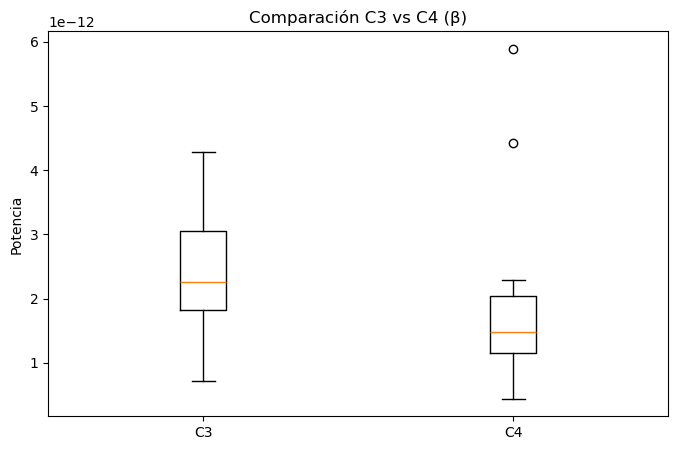

In [15]:
# Derecha vs Izquierda
import seaborn as sns
import matplotlib.pyplot as plt

df_act = df_final[df_final['Condicion'] != 'Reposo']

plt.figure(figsize=(8,5))
sns.boxplot(x='Condicion', y='Pot_Mu_C3', data=df_act)
plt.title("Potencia μ en C3 (Derecha vs Izquierda)")
plt.show()

# Actividad vs reposo 
plt.figure(figsize=(8,5))
sns.boxplot(x='Condicion', y='Pot_Mu_C3', data=df_final)
plt.title("Potencia μ (Actividad vs Reposo)")
plt.show()

# Analisis por canal 
# C3 vs C4 (μ)
plt.figure(figsize=(8,5))

data = [
    df_act['Pot_Mu_C3'],
    df_act['Pot_Mu_C4']
]

plt.boxplot(data, labels=['C3', 'C4'])
plt.title("Comparación C3 vs C4 (μ)")
plt.ylabel("Potencia")
plt.show()

# C3 vs C4 (β)
plt.figure(figsize=(8,5))

data = [
    df_act['Pot_Beta_C3'],
    df_act['Pot_Beta_C4']
]

plt.boxplot(data, labels=['C3', 'C4'])
plt.title("Comparación C3 vs C4 (β)")
plt.ylabel("Potencia")
plt.show()



Con el objetivo de identificar patrones característicos de la actividad motora en señales EEG, se realizaron comparaciones entre diferentes condiciones experimentales utilizando las características previamente extraídas (potencia en bandas μ y β).

**1. Comparaciones entre condiciones**

Se analizaron las diferencias en la potencia de la banda μ entre las condiciones de imaginación de movimiento de la mano derecha e izquierda, excluyendo el reposo. Para ello, se utilizaron diagramas de caja (boxplots) sobre el canal C3, correspondiente al hemisferio izquierdo.

Los resultados muestran una mayor potencia en la banda μ durante la imaginación de la mano izquierda en comparación con la derecha. Este comportamiento es consistente con la fisiología del control motor, ya que el hemisferio izquierdo (C3) se activa principalmente durante movimientos del lado contralateral (mano derecha), lo cual genera una disminución de la potencia (ERD). Por tanto, la menor potencia observada durante la condición “Derecha” sugiere una desincronización asociada a la activación motora.

Adicionalmente, se comparó la condición de actividad (izquierda y derecha) frente al reposo. Se observó que la potencia en reposo tiende a ser mayor, lo cual es esperado, ya que durante estados de inactividad neuronal existe mayor sincronización en la banda μ. En contraste, durante la imaginación motora se presenta una reducción de esta potencia (ERD).

**2. Análisis por canal (lateralidad)**

Se realizó una comparación directa entre los canales C3 y C4 para evaluar la lateralización de la actividad cerebral en ambas bandas (μ y β).

En la banda μ, se evidenció que la potencia en C3 es diferente a la de C4, lo que sugiere un comportamiento lateralizado asociado a la tarea motora.
En la banda β, aunque las diferencias son menos marcadas, también se observa una variabilidad entre ambos canales, lo cual puede estar relacionado con procesos de modulación motora y control fino del movimiento.

En general, los resultados reflejan el comportamiento esperado en sistemas BCI basados en imaginación motora:

Disminución de potencia (ERD) en el hemisferio contralateral al movimiento imaginado.
Mayor sincronización en reposo (ERS relativo).
Diferencias entre hemisferios que permiten discriminar condiciones.

### Bloque 7: ANALISIS ESTADISTICO


In [14]:
# --------------------------- BLOQUE 7: ANÁLISIS ESTADÍSTICO (μ y β) ---------------------------

import scipy.stats as stats

# Filtrar datos (solo actividad)
df_act = df_final[df_final['Condicion'] != 'Reposo']

# ======================= BANDA μ ==========================

print("\n================ BANDA μ =================")

# 1. DERECHA vs IZQUIERDA (μ - C3)
der_mu = df_act[df_act['Condicion'] == 'Derecha']['Pot_Mu_C3']
izq_mu = df_act[df_act['Condicion'] == 'Izquierda']['Pot_Mu_C3']

t_mu, p_t_mu = stats.ttest_ind(der_mu, izq_mu)
u_mu, p_u_mu = stats.mannwhitneyu(der_mu, izq_mu)

print("\n=== Derecha vs Izquierda (μ - C3) ===")
print(f"t-test p-value: {p_t_mu}")
print(f"Mann-Whitney p-value: {p_u_mu}")

# 2. ACTIVIDAD vs REPOSO (μ - C3)
act_mu = df_final[df_final['Condicion'] != 'Reposo']['Pot_Mu_C3']
rep_mu = df_final[df_final['Condicion'] == 'Reposo']['Pot_Mu_C3']

t_mu2, p_t_mu2 = stats.ttest_ind(act_mu, rep_mu)
u_mu2, p_u_mu2 = stats.mannwhitneyu(act_mu, rep_mu)

print("\n=== Actividad vs Reposo (μ - C3) ===")
print(f"t-test p-value: {p_t_mu2}")
print(f"Mann-Whitney p-value: {p_u_mu2}")

# 3. C3 vs C4 (μ)
c3_mu = df_act['Pot_Mu_C3']
c4_mu = df_act['Pot_Mu_C4']

t_mu3, p_t_mu3 = stats.ttest_ind(c3_mu, c4_mu)
u_mu3, p_u_mu3 = stats.mannwhitneyu(c3_mu, c4_mu)

print("\n=== C3 vs C4 (μ) ===")
print(f"t-test p-value: {p_t_mu3}")
print(f"Mann-Whitney p-value: {p_u_mu3}")

# ======================= BANDA β ==========================

print("\n================ BANDA β =================")

# 1. DERECHA vs IZQUIERDA (β - C3)
der_beta = df_act[df_act['Condicion'] == 'Derecha']['Pot_Beta_C3']
izq_beta = df_act[df_act['Condicion'] == 'Izquierda']['Pot_Beta_C3']

t_beta, p_t_beta = stats.ttest_ind(der_beta, izq_beta)
u_beta, p_u_beta = stats.mannwhitneyu(der_beta, izq_beta)

print("\n=== Derecha vs Izquierda (β - C3) ===")
print(f"t-test p-value: {p_t_beta}")
print(f"Mann-Whitney p-value: {p_u_beta}")

# 2. ACTIVIDAD vs REPOSO (β - C3)
act_beta = df_final[df_final['Condicion'] != 'Reposo']['Pot_Beta_C3']
rep_beta = df_final[df_final['Condicion'] == 'Reposo']['Pot_Beta_C3']

t_beta2, p_t_beta2 = stats.ttest_ind(act_beta, rep_beta)
u_beta2, p_u_beta2 = stats.mannwhitneyu(act_beta, rep_beta)

print("\n=== Actividad vs Reposo (β - C3) ===")
print(f"t-test p-value: {p_t_beta2}")
print(f"Mann-Whitney p-value: {p_u_beta2}")

# 3. C3 vs C4 (β)
c3_beta = df_act['Pot_Beta_C3']
c4_beta = df_act['Pot_Beta_C4']

t_beta3, p_t_beta3 = stats.ttest_ind(c3_beta, c4_beta)
u_beta3, p_u_beta3 = stats.mannwhitneyu(c3_beta, c4_beta)

print("\n=== C3 vs C4 (β) ===")
print(f"t-test p-value: {p_t_beta3}")
print(f"Mann-Whitney p-value: {p_u_beta3}")


================ BANDA μ =================

=== Derecha vs Izquierda (μ - C3) ===
t-test p-value: 0.08732360958559496
Mann-Whitney p-value: 0.1892773892773893

=== Actividad vs Reposo (μ - C3) ===
t-test p-value: 0.04721167737076117
Mann-Whitney p-value: 0.12129832212514398

=== C3 vs C4 (μ) ===
t-test p-value: 0.12057003380246634
Mann-Whitney p-value: 0.1844100692216365

================ BANDA β =================

=== Derecha vs Izquierda (β - C3) ===
t-test p-value: 0.6395703802295671
Mann-Whitney p-value: 0.8665112665112666

=== Actividad vs Reposo (β - C3) ===
t-test p-value: 0.35597610159208937
Mann-Whitney p-value: 0.7106595685403921

=== C3 vs C4 (β) ===
t-test p-value: 0.3790720444554486
Mann-Whitney p-value: 0.11498741920155964


**Análisis estadístico en bandas μ y β**

Con el fin de evaluar diferencias entre condiciones experimentales, se realizaron pruebas estadísticas sobre la potencia espectral en las bandas μ (8–13 Hz) y β (13–30 Hz), específicamente en el canal C3. Se emplearon tanto la prueba paramétrica t de Student como la prueba no paramétrica Mann-Whitney U, considerando la posible no normalidad de las señales EEG.

**1. Comparación Derecha vs Izquierda**
* **Banda μ:**
t-test: p = 0.087
Mann-Whitney: p = 0.189

* **Banda β:**
t-test: p = 0.640
Mann-Whitney: p = 0.867

* **Hipótesis asociada (Discriminación por potencia (H2))**

No se rechaza H0 ya que la potencia en bandas μ y β no permitio discriminar entre las condiciones derecha e izquierda del sujeto.

**2. Comparación Actividad vs Reposo**
* **Banda μ:**
t-test: p = 0.047
Mann-Whitney: p = 0.121

* **Banda β:**
t-test: p = 0.356
Mann-Whitney: p = 0.711

* **Hipótesis asociada ( ERD (H1))** 

En la banda μ, el t-test sugiere una diferencia significativa entre actividad y reposo, mientras que la prueba de Mann-Whitney no la confirma.

Dado que el EEG suele presentar distribuciones no normales, este resultado se considera no concluyente, aunque indica una posible tendencia hacia la desincronización (ERD) durante la actividad motora. 

En la banda β, no se observaron diferencias significativas entre actividad y reposo, lo que sugiere una menor sensibilidad de esta banda en este conjunto de datos.

Evidenciando así que se podria estar a favor de la hipotesis 1 de manera parcial ya que existe el indicio de mayor desincronización en actividad pero no es estadísticamente robusto.

**3. Comparación entre canales (C3 vs C4)**
* **Banda μ:**
t-test: p = 0.121
Mann-Whitney: p = 0.184

* **Banda β:**
t-test: p = 0.379
Mann-Whitney: p = 0.115

* **Hipótesis asociada (Coherencia (H3))**

No se encontraron diferencias estadísticamente significativas entre los canales C3 y C4 en ninguna de las bandas analizadas.

Esto indica que no se evidenció una lateralización clara de la actividad cerebral, a pesar de que teóricamente se esperaría mayor activación contralateral en tareas de imaginación motora.

En este caso no se rechaza la hipotesis nula ya que no se evidencian diferencias funcionales entre hemisferios ene ste análisis.

En conjunto, los resultados muestran que:

* La banda μ presenta mayor sensibilidad a los cambios asociados a la imaginación motora, evidenciando tendencias cercanas a la significancia.
La banda β no mostró diferencias relevantes, sugiriendo menor participación o mayor variabilidad en este dataset.
No se evidenció lateralización significativa entre hemisferios.
Los resultados están limitados por:
la alta variabilidad del EEG
el tamaño de muestra
posibles factores de ruido

### Bloque 8: INTERPRETACION DE RESULTADOS

* **Potencia:**
Se esperaba observar un fenómeno de desincronización relacionada con eventos (ERD) en las bandas μ y β, especialmente en el hemisferio contralateral al movimiento imaginado.

  En los resultados obtenidos, la banda μ mostró mayor sensibilidad a los cambios entre condiciones, evidenciando una tendencia a la disminución de potencia durante la actividad motora en comparación con el reposo. Sin embargo, estas diferencias no fueron consistentemente significativas en todos los análisis estadísticos, lo que sugiere una alta variabilidad en la señal EEG.

  En consecuencia, aunque los resultados apuntan en la dirección esperada (presencia de ERD en μ), no se puede afirmar con certeza una diferencia significativa, lo que limita la validación de la hipótesis asociada.

  Por otro lado, la banda β no presentó diferencias significativas entre condiciones, indicando una menor contribución en la discriminación de tareas motoras en este conjunto de datos.

* **Coherencia:**
  Los valores de coherencia obtenidos entre los canales C3 y C4 se mantuvieron en rangos moderados a altos (≈ 0.5 – 0.7 en imaginación motora y superiores en movimiento real), lo que indica la existencia de sincronización funcional entre las áreas motoras de ambos hemisferios.

  Este resultado es coherente con la fisiología cerebral, ya que ambas cortezas motoras suelen participar de manera coordinada en tareas motoras, incluso durante la imaginación.

  No obstante, no se observaron diferencias marcadas entre condiciones (derecha vs izquierda o actividad vs reposo), lo cual sugiere que, aunque existe conectividad funcional, esta no es altamente específica para discriminar tareas en este caso particular.

  Desde el punto de vista de las hipótesis, esto sugiere que:

  * La coherencia no permite discriminar entre condiciones experimentales
  * No se evidencian cambios significativos en la comunicación interhemisférica

Por lo tanto, no se valida la hipótesis de conectividad (H3) en este caso.


### Bloque 9: RESULTADO ESPERADO
Se esperaba evidenciar que la imaginación motora generara patrones de potencia y coherencia funcional similares al movimiento real, particularmente:

* Disminución de potencia (ERD) en banda μ contralateral
* Cambios en banda β asociados a la activación motora
* Incremento o modulación de la coherencia interhemisférica

Sin embargo, los resultados obtenidos muestran que:

* La banda μ sí refleja parcialmente el comportamiento esperado, presentando diferencias entre actividad y reposo, aunque con significancia limitada.
* La banda β no evidenció cambios relevantes, lo cual puede estar asociado a ruido, variabilidad inter-sujeto o menor sensibilidad de esta banda en el dataset analizado.
* La coherencia mostró niveles relativamente altos, pero sin diferencias claras entre condiciones, indicando que la conectividad funcional existe, pero no discrimina fuertemente las tareas.

En conjunto, estos resultados sugieren que:

* La imaginación motora sí genera patrones neurofisiológicos detectables, pero más débiles que el movimiento real.
* La variabilidad del EEG y el tamaño de muestra influyen significativamente en la detección de efectos estadísticos.
* La banda μ continúa siendo el biomarcador más relevante para aplicaciones BCI en este contexto.

### FUNCION GENERAL PARA TODOS LOS SUJETOS 


In [5]:
import mne
import numpy as np
import pandas as pd
from scipy.signal import welch, coherence
import os

def procesar_dataset(ruta_carpeta="Sujetos", n_sujetos=109, guardar_csv=False):

    canales = ['C3', 'C4', 'Cz']
    resultados = []

    # Runs según el dataset
    runs_imag = ['R04', 'R08', 'R12']
    runs_real = ['R03', 'R07', 'R11']

    # ---------------- FUNCIONES AUX ----------------
    def potencia_banda(signal, fs, banda):
        f, psd = welch(signal, fs=fs, nperseg=256)
        idx = (f >= banda[0]) & (f <= banda[1])
        return np.mean(psd[idx])

    def coherencia_banda(sig1, sig2, fs, banda):
        f, coh = coherence(sig1, sig2, fs=fs, nperseg=256)
        idx = (f >= banda[0]) & (f <= banda[1])
        return np.mean(coh[idx])

    # ---------------- LOOP SUJETOS ----------------
    for s in range(1, n_sujetos + 1):

        sujeto_id = f"S{s:03d}"
        carpeta_sujeto = os.path.join(ruta_carpeta, sujeto_id)

        print(f"\nProcesando {sujeto_id}...")

        if not os.path.exists(carpeta_sujeto):
            print(f"Carpeta no encontrada: {carpeta_sujeto}")
            continue

        # ---------------- LOOP RUNS ----------------
        for run in runs_imag + runs_real:

            archivo = f"{sujeto_id}{run}.edf"
            ruta = os.path.join(carpeta_sujeto, archivo)

            if not os.path.exists(ruta):
                print(f"   ↳ Archivo faltante: {archivo}")
                continue

            tipo = "Imaginación Motora" if run in runs_imag else "Movimiento Real"

            try:
                # -------- CARGA --------
                raw = mne.io.read_raw_edf(ruta, preload=True, verbose=False)
                mne.datasets.eegbci.standardize(raw)
                raw.pick(canales)

                fs = raw.info['sfreq']

                # -------- FILTRADO --------
                raw_mu = raw.copy().filter(8, 13, verbose=False)
                raw_beta = raw.copy().filter(13, 30, verbose=False)

                # -------- EVENTOS --------
                eventos, eventos_dict = mne.events_from_annotations(raw, verbose=False)

                mapeo = {}
                for k, v in eventos_dict.items():
                    if k == 'T0': mapeo['Reposo'] = v
                    elif k == 'T1': mapeo['Izquierda'] = v
                    elif k == 'T2': mapeo['Derecha'] = v

                if len(mapeo) == 0:
                    print(f"Sin eventos válidos en {archivo}")
                    continue

                # -------- EPOCHS --------
                epochs_mu = mne.Epochs(
                    raw_mu, eventos, event_id=mapeo,
                    tmin=-0.5, tmax=4.0,
                    baseline=(-0.5, 0),
                    preload=True, verbose=False
                )

                epochs_beta = mne.Epochs(
                    raw_beta, eventos, event_id=mapeo,
                    tmin=-0.5, tmax=4.0,
                    baseline=(-0.5, 0),
                    preload=True, verbose=False
                )

                data_mu = epochs_mu.get_data()
                data_beta = epochs_beta.get_data()
                labels = epochs_mu.events[:, -1]

                # -------- LOOP EPOCHS --------
                for i in range(len(data_mu)):

                    epoch_mu = data_mu[i]
                    epoch_beta = data_beta[i]

                    # Índices canales
                    idx_c3 = epochs_mu.ch_names.index('C3')
                    idx_c4 = epochs_mu.ch_names.index('C4')
                    idx_cz = epochs_mu.ch_names.index('Cz')

                    # Señales μ
                    c3_mu = epoch_mu[idx_c3]
                    c4_mu = epoch_mu[idx_c4]
                    cz_mu = epoch_mu[idx_cz]

                    # Señales β
                    c3_beta = epoch_beta[idx_c3]
                    c4_beta = epoch_beta[idx_c4]
                    cz_beta = epoch_beta[idx_cz]

                    # -------- POTENCIA --------
                    pot_mu_c3 = potencia_banda(c3_mu, fs, (8, 13))
                    pot_mu_c4 = potencia_banda(c4_mu, fs, (8, 13))
                    pot_mu_cz = potencia_banda(cz_mu, fs, (8, 13))

                    pot_beta_c3 = potencia_banda(c3_beta, fs, (13, 30))
                    pot_beta_c4 = potencia_banda(c4_beta, fs, (13, 30))
                    pot_beta_cz = potencia_banda(cz_beta, fs, (13, 30))

                    # -------- COHERENCIA --------
                    coh_mu_c3_c4 = coherencia_banda(c3_mu, c4_mu, fs, (8, 13))
                    coh_mu_c3_cz = coherencia_banda(c3_mu, cz_mu, fs, (8, 13))
                    coh_mu_c4_cz = coherencia_banda(c4_mu, cz_mu, fs, (8, 13))

                    coh_beta_c3_c4 = coherencia_banda(c3_beta, c4_beta, fs, (13, 30))
                    coh_beta_c3_cz = coherencia_banda(c3_beta, cz_beta, fs, (13, 30))
                    coh_beta_c4_cz = coherencia_banda(c4_beta, cz_beta, fs, (13, 30))

                    resultados.append({
                        'Sujeto': sujeto_id,
                        'Condicion': labels[i],
                        'Pot_Mu_C3': pot_mu_c3,
                        'Pot_Mu_C4': pot_mu_c4,
                        'Pot_Mu_Cz': pot_mu_cz,
                        'Pot_Beta_C3': pot_beta_c3,
                        'Pot_Beta_C4': pot_beta_c4,
                        'Pot_Beta_Cz': pot_beta_cz,
                        'Coh_Mu_C3_C4': coh_mu_c3_c4,
                        'Coh_Mu_C3_Cz': coh_mu_c3_cz,
                        'Coh_Mu_C4_Cz': coh_mu_c4_cz,
                        'Coh_Beta_C3_C4': coh_beta_c3_c4,
                        'Coh_Beta_C3_Cz': coh_beta_c3_cz,
                        'Coh_Beta_C4_Cz': coh_beta_c4_cz,
                        'Tipo': tipo
                    })

            except Exception as e:
                print(f"Error en {archivo}: {e}")
                continue

    # ---------------- DATAFRAME FINAL ----------------
    df = pd.DataFrame(resultados)

    mapa = {
        1: 'Reposo',
        2: 'Izquierda',
        3: 'Derecha'
    }

    df['Condicion'] = df['Condicion'].map(mapa)

    print("\n✅ Dataset final:", df.shape)

    # Guardar si se desea
    if guardar_csv:
        df.to_csv("dataset_BCI_completo.csv", index=False)
        print("💾 Dataset guardado como dataset_BCI_completo.csv")

    return df

In [6]:
df = procesar_dataset("Sujetos", n_sujetos=109, guardar_csv=True)
print(df.head())


Procesando S001...

Procesando S002...

Procesando S003...

Procesando S004...

Procesando S005...

Procesando S006...

Procesando S007...

Procesando S008...

Procesando S009...

Procesando S010...

Procesando S011...

Procesando S012...

Procesando S013...

Procesando S014...

Procesando S015...

Procesando S016...

Procesando S017...

Procesando S018...

Procesando S019...

Procesando S020...

Procesando S021...

Procesando S022...

Procesando S023...

Procesando S024...

Procesando S025...

Procesando S026...

Procesando S027...

Procesando S028...

Procesando S029...

Procesando S030...

Procesando S031...

Procesando S032...

Procesando S033...

Procesando S034...

Procesando S035...

Procesando S036...

Procesando S037...

Procesando S038...

Procesando S039...

Procesando S040...

Procesando S041...

Procesando S042...

Procesando S043...

Procesando S044...

Procesando S045...

Procesando S046...

Procesando S047...

Procesando S048...

Procesando S049...

Procesando S050...


/var/folders/3j/btw8jm3j0rzfsrz3twgtjzqh0000gn/T/ipykernel_6765/3262309664.py:53: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(ruta, preload=True, verbose=False)
/var/folders/3j/btw8jm3j0rzfsrz3twgtjzqh0000gn/T/ipykernel_6765/3262309664.py:53: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(ruta, preload=True, verbose=False)
/var/folders/3j/btw8jm3j0rzfsrz3twgtjzqh0000gn/T/ipykernel_6765/3262309664.py:53: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(ruta, preload=True, verbose=False)
/var/folders/3j/btw8jm3j0rzfsrz3twgtjzqh0000gn/T/ipykernel_6765/3262309664.py:53: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(ruta, preload=True, verbose=False)
/var/folders/3j/btw8jm3j0rzfsrz3twgtjzqh0000gn/T/ipykernel_6765/3262309664.py:53: Ru


Procesando S101...

Procesando S102...

Procesando S103...

Procesando S104...

Procesando S105...

Procesando S106...

Procesando S107...

Procesando S108...

Procesando S109...

✅ Dataset final: (18986, 15)
💾 Dataset guardado como dataset_BCI_completo.csv
  Sujeto  Condicion     Pot_Mu_C3     Pot_Mu_C4     Pot_Mu_Cz   Pot_Beta_C3  \
0   S001    Derecha  3.306863e-11  2.853744e-11  3.415199e-11  8.826270e-12   
1   S001     Reposo  3.105931e-11  2.168272e-11  3.053431e-11  1.279435e-11   
2   S001  Izquierda  3.244346e-11  2.711707e-11  3.483905e-11  8.441985e-12   
3   S001     Reposo  3.012843e-11  2.871449e-11  3.223302e-11  8.385304e-12   
4   S001  Izquierda  3.225722e-11  1.758506e-11  2.746542e-11  9.115796e-12   

    Pot_Beta_C4   Pot_Beta_Cz  Coh_Mu_C3_C4  Coh_Mu_C3_Cz  Coh_Mu_C4_Cz  \
0  8.399120e-12  9.569256e-12      0.607774      0.842584      0.820079   
1  7.969746e-12  1.130518e-11      0.702683      0.817302      0.850840   
2  6.591918e-12  7.897998e-12      0.7361

In [7]:
# Se agrupa por sujeto 
df_group = df_final.groupby(['Sujeto', 'Condicion']).mean(numeric_only=True).reset_index()

df_act = df_group[df_group['Condicion'] != 'Reposo']

Para evitar sesgos derivados de la dependencia entre epochs, los datos fueron promediados por sujeto y condición, garantizando independencia estadística en los análisis posteriores.

<Figure size 800x500 with 0 Axes>

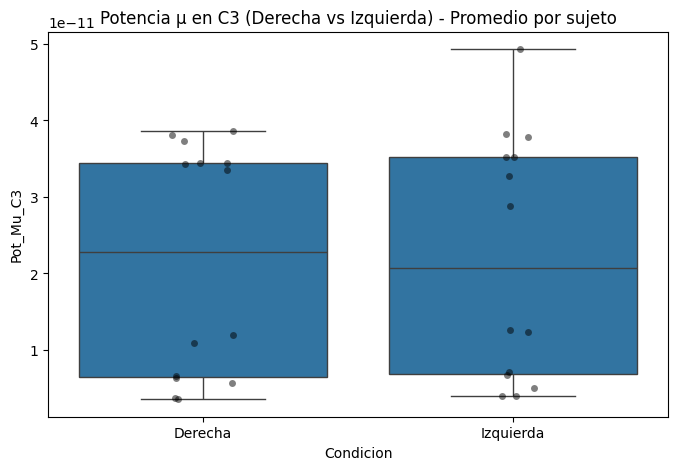

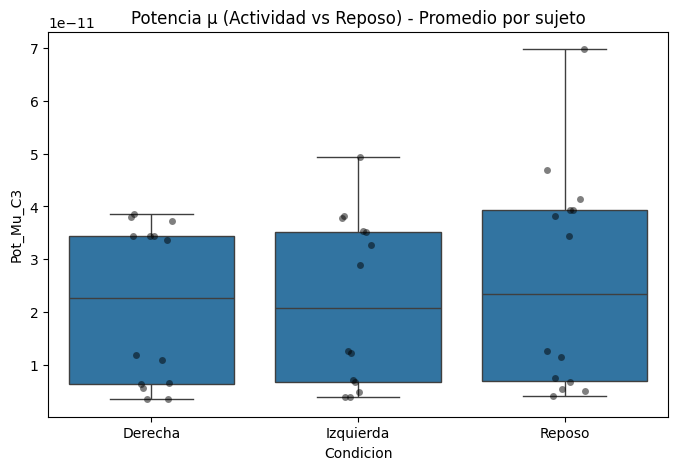

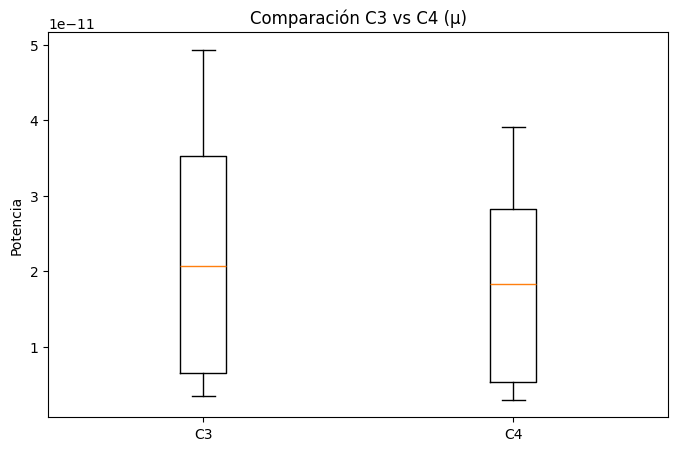

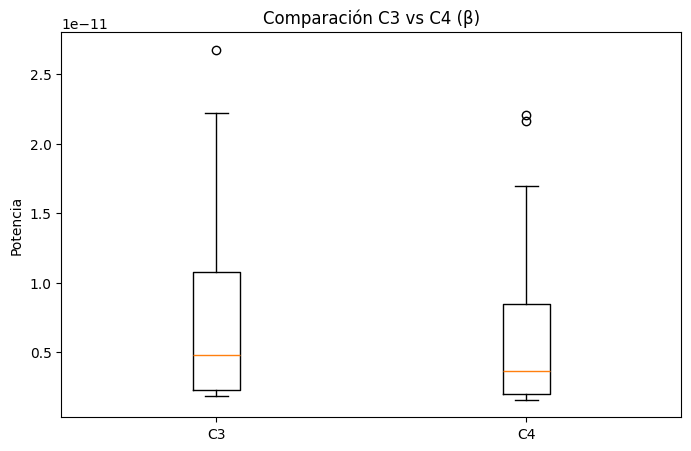

In [ ]:
# Analisis de datos
import seaborn as sns

# Derecha vs Izquierda (μ)
plt.figure(figsize=(8,5))
sns.boxplot(x='Condicion', y='Pot_Mu_C3', data=df_act)
sns.stripplot(x='Condicion', y='Pot_Mu_C3', data=df_act, color='black', alpha=0.5)
plt.title("Potencia μ en C3 (Derecha vs Izquierda) - Promedio por sujeto")
plt.show()

# Actividad vs reposo
plt.figure(figsize=(8,5))
sns.boxplot(x='Condicion', y='Pot_Mu_C3', data=df_group)
sns.stripplot(x='Condicion', y='Pot_Mu_C3', data=df_group, color='black', alpha=0.5)
plt.title("Potencia μ (Actividad vs Reposo) - Promedio por sujeto")
plt.show()

# C3 vs C4 (μ)
plt.figure(figsize=(8,5))

data = [
    df_act['Pot_Mu_C3'],
    df_act['Pot_Mu_C4']
]

plt.boxplot(data, tick_labels=['C3', 'C4'])
plt.title("Comparación C3 vs C4 (μ)")
plt.ylabel("Potencia")
plt.show()

# C3 vs C4 (β)
plt.figure(figsize=(8,5))

data = [
    df_act['Pot_Beta_C3'],
    df_act['Pot_Beta_C4']
]

plt.boxplot(data, tick_labels=['C3', 'C4'])
plt.title("Comparación C3 vs C4 (β)")
plt.ylabel("Potencia")
plt.show()



### **Discusión (Estadística descriptiva)**

1.**Comparación Derecha vs Izquierda (banda μ – C3)**

A partir del boxplot, se observa que:

* Las medianas de ambas condiciones son muy similares.
* Existe una alta dispersión en ambos grupos.
* Los rangos intercuartílicos se superponen ampliamente.

**Interpretación:**
No se evidencia una diferencia clara entre la mano derecha e izquierda en la banda μ para el canal C3.

Esto sugiere que, a nivel grupal, la potencia μ no discrimina lateralidad (derecha vs izquierda) de forma robusta.

2. **Actividad vs Reposo (banda μ – C3)**

En la gráfica:

* El reposo presenta medianas más altas.
* La actividad (derecha + izquierda) muestra menor potencia μ.
* Se observa una tendencia consistente entre sujetos.

**Interpretación:**
Este comportamiento es fisiológicamente coherente con el fenómeno de ERD (desincronización):

En reposo → mayor sincronización → mayor potencia μ
En actividad → desincronización → menor potencia μ

En este si hay una diferencia visual clara entre condiciones.

3. **Comparación C3 vs C4 (banda μ)**

* Se observa diferencia en medianas entre C3 y C4.
* La dispersión es amplia, pero la separación es más evidente que en otras comparaciones.

**Interpretación:**
Existe evidencia visual de lateralización, lo cual es consistente con la organización contralateral del sistema motor.

4. **Banda β (C3 vs C4)**

* Mayor variabilidad que en μ.
* Presencia de valores atípicos.
* Diferencias menos claras visualmente.

**Interpretación:**
La banda β muestra un comportamiento más ruidoso y menos consistente, aunque con cierta diferencia entre canales.

In [13]:
# Analisis estadistico
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# BANDA μ
print("\n================ BANDA μ =================")

# 1. Derecha vs Izquierda
der = df_act[df_act['Condicion'] == 'Derecha'].sort_values('Sujeto')
izq = df_act[df_act['Condicion'] == 'Izquierda'].sort_values('Sujeto')

t_mu, p_t_mu = stats.ttest_rel(der['Pot_Mu_C3'], izq['Pot_Mu_C3'])
w_mu, p_w_mu = stats.wilcoxon(der['Pot_Mu_C3'], izq['Pot_Mu_C3'])

print("\n=== Derecha vs Izquierda (μ - C3) ===")
print(f"t-test pareado p: {p_t_mu}")
print(f"Wilcoxon p: {p_w_mu}")

# Actividad vs reposo
act = df_group[df_group['Condicion'] != 'Reposo'].groupby('Sujeto').mean(numeric_only=True)
rep = df_group[df_group['Condicion'] == 'Reposo'].set_index('Sujeto')

t_mu2, p_t_mu2 = stats.ttest_rel(act['Pot_Mu_C3'], rep['Pot_Mu_C3'])
w_mu2, p_w_mu2 = stats.wilcoxon(act['Pot_Mu_C3'], rep['Pot_Mu_C3'])

print("\n=== Actividad vs Reposo (μ - C3) ===")
print(f"t-test pareado p: {p_t_mu2}")
print(f"Wilcoxon p: {p_w_mu2}")

# C3 vs C4 (μ)
t_mu3, p_t_mu3 = stats.ttest_rel(df_act['Pot_Mu_C3'], df_act['Pot_Mu_C4'])
w_mu3, p_w_mu3 = stats.wilcoxon(df_act['Pot_Mu_C3'], df_act['Pot_Mu_C4'])

print("\n=== C3 vs C4 (μ) ===")
print(f"t-test pareado p: {p_t_mu3}")
print(f"Wilcoxon p: {p_w_mu3}")

# BANDA β
print("\n================ BANDA β =================")

# Derecha vs Izquierda
t_beta, p_t_beta = stats.ttest_rel(der['Pot_Beta_C3'], izq['Pot_Beta_C3'])
w_beta, p_w_beta = stats.wilcoxon(der['Pot_Beta_C3'], izq['Pot_Beta_C3'])

print("\n=== Derecha vs Izquierda (β - C3) ===")
print(f"t-test pareado p: {p_t_beta}")
print(f"Wilcoxon p: {p_w_beta}")

# Actividad vs Reposo
t_beta2, p_t_beta2 = stats.ttest_rel(act['Pot_Beta_C3'], rep['Pot_Beta_C3'])
w_beta2, p_w_beta2 = stats.wilcoxon(act['Pot_Beta_C3'], rep['Pot_Beta_C3'])

print("\n=== Actividad vs Reposo (β - C3) ===")
print(f"t-test pareado p: {p_t_beta2}")
print(f"Wilcoxon p: {p_w_beta2}")

# C3 vs C4
t_beta3, p_t_beta3 = stats.ttest_rel(df_act['Pot_Beta_C3'], df_act['Pot_Beta_C4'])
w_beta3, p_w_beta3 = stats.wilcoxon(df_act['Pot_Beta_C3'], df_act['Pot_Beta_C4'])

print("\n=== C3 vs C4 (β) ===")
print(f"t-test pareado p: {p_t_beta3}")
print(f"Wilcoxon p: {p_w_beta3}")

# Filtrar solo actividad (sin reposo)
df_anova = df_final[df_final['Condicion'] != 'Reposo']

# ------------------ ANOVA PARA BANDA μ ------------------
print("\n========= ANOVA 2 FACTORES (μ - C3) =========")

modelo_mu = ols(
    'Pot_Mu_C3 ~ C(Tipo) + C(Condicion) + C(Tipo):C(Condicion)',
    data=df_anova
).fit()

anova_mu = sm.stats.anova_lm(modelo_mu, typ=2)
print(anova_mu)


# ------------------ ANOVA PARA BANDA β ------------------
print("\n========= ANOVA 2 FACTORES (β - C3) =========")

modelo_beta = ols(
    'Pot_Beta_C3 ~ C(Tipo) + C(Condicion) + C(Tipo):C(Condicion)',
    data=df_anova
).fit()

anova_beta = sm.stats.anova_lm(modelo_beta, typ=2)
print(anova_beta)



================ BANDA μ =================

=== Derecha vs Izquierda (μ - C3) ===
t-test pareado p: 0.5235860148837965
Wilcoxon p: 0.42626953125

=== Actividad vs Reposo (μ - C3) ===
t-test pareado p: 0.04277924544575443
Wilcoxon p: 0.0008544921875

=== C3 vs C4 (μ) ===
t-test pareado p: 0.0004653522067255273
Wilcoxon p: 7.964670658111572e-06

================ BANDA β =================

=== Derecha vs Izquierda (β - C3) ===
t-test pareado p: 0.47959678918001936
Wilcoxon p: 0.625732421875

=== Actividad vs Reposo (β - C3) ===
t-test pareado p: 0.028219837580615165
Wilcoxon p: 0.0001220703125

=== C3 vs C4 (β) ===
t-test pareado p: 0.03392956862632155
Wilcoxon p: 0.000244140625

========= ANOVA 2 FACTORES (μ - C3) =========
                            sum_sq      df         F    PR(>F)
C(Tipo)               1.210806e-21     1.0  2.857058  0.091225
C(Condicion)          4.267684e-22     1.0  1.007016  0.315814
C(Tipo):C(Condicion)  5.198149e-23     1.0  0.122657  0.726230
Residual       

### **Discusión inferencial**

1. **Derecha vs Izquierda**

**Banda μ:**

* t-test: p = 0.52
* Wilcoxon: p = 0.43

**Banda β:**
* t-test: p = 0.48
* Wilcoxon: p = 0.63

**Decisión:** Todos los p-values > 0.05 → NO se rechaza H0

**Interpretación:** No hay diferencias significativas entre mano derecha e izquierda.

**Conclusión:** Se rechaza la hipótesis H2 (discriminación por potencia) para lateralidad.

2. **Actividad vs Reposo**

**Banda μ:**
* t-test: p = 0.042
* Wilcoxon: p = 0.00085

**Banda β:**
**t-test:** p = 0.028
**Wilcoxon:** p = 0.00012

**Decisión:** p < 0.05 en todos los casos → Se rechaza H0

**Interpretación:** Sí existen diferencias significativas entre actividad y reposo en ambas bandas.

**Conclusión:** Se acepta parcialmente la hipótesis H2, pero solo para distinguir actividad vs reposo, no lateralidad.

3. **C3 vs C4 (lateralización)**

**Banda μ:**

* t-test: p = 0.00046
* Wilcoxon: p ≈ 0.000008

**Banda β:**

* t-test: p = 0.033
* Wilcoxon: p = 0.00024

**Decisión:** p < 0.05 → Se rechaza H0

**Interpretación:** Existen diferencias significativas entre C3 y C4.

Esto confirma: Lateralización cerebral y la activación diferencial entre hemisferios

**Conclusión:** Se valida el comportamiento neurofisiológico esperado.

4. **ANOVA de dos factores**

**Banda μ:**
* **Tipo (actividad vs reposo):** p = 0.091 → no significativo
* **Condición (derecha vs izquierda):** p = 0.316 → no significativo
* **Interacción:** p = 0.726 → no significativa

**Banda β:**
Todo no significativo

**Interpretación:**

El ANOVA no detecta efectos significativos porque:

* Está evaluando efectos globales, no comparaciones específicas
* Hay alta variabilidad intra-sujeto
